<a href="https://colab.research.google.com/github/switlanakostyuk-ctrl/Apollo/blob/main/%22HW_11_2_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [57]:
from google.colab import files
uploaded = files.upload()

Saving yulu_rental.csv to yulu_rental (4).csv


In [58]:
import pandas as pd

df = pd.read_csv('yulu_rental.csv')

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [60]:
monthly_avg = df['count'].resample('ME').mean()

# через Pandas

Text(0, 0.5, 'Середня кількість оренд')

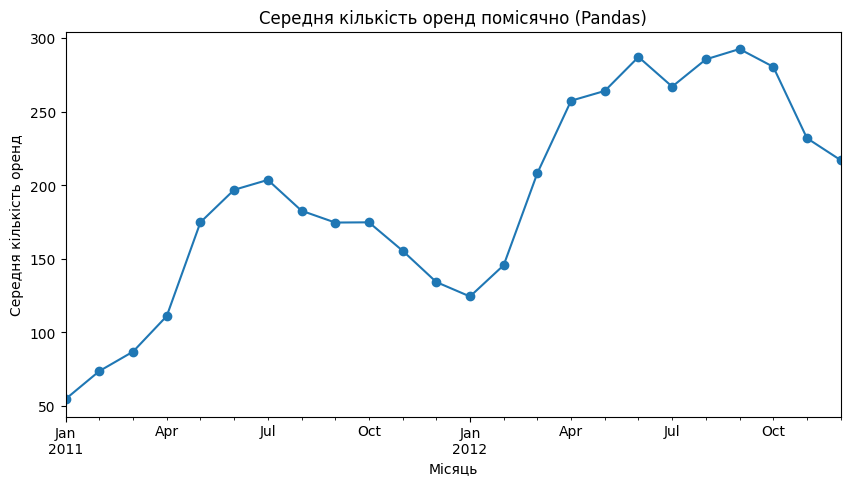

In [61]:
ax = monthly_avg.plot(
    figsize=(10, 5),
    marker='o',
    color='#1f77b4',
    title='Середня кількість оренд помісячно (Pandas)'
)

ax.set_xlabel('Місяць')
ax.set_ylabel('Середня кількість оренд')

# через Matplotlib

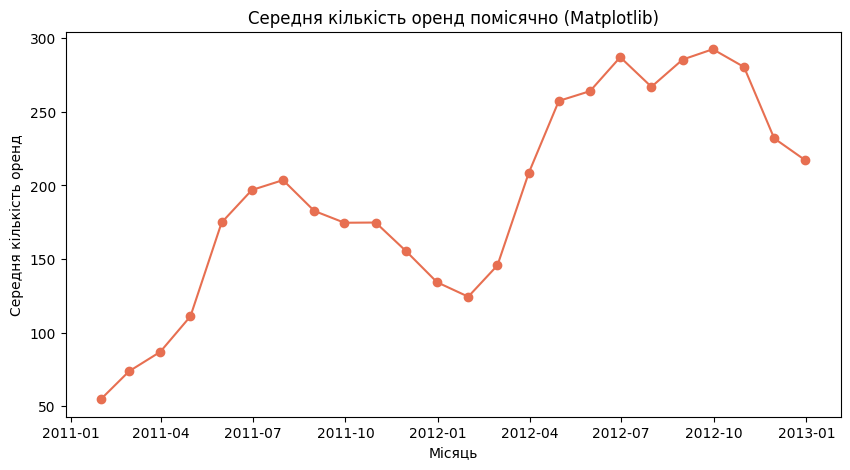

In [62]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o',
    color='#e76f51'
)

ax.set_title('Середня кількість оренд помісячно (Matplotlib)')
ax.set_xlabel('Місяць')
ax.set_ylabel('Середня кількість оренд')

plt.show()

Matplotlib мені більше подобається, бо він дає більше контролю над налаштуванням графіка. Можна детальніше налаштовувати підписи, масштаб, стиль графіка та комбінувати кілька елементів на одному полотні.

Pandas-підхід зручний для швидкого аналізу, але Matplotlib краще підходить для створення більш презентабельних візуалізацій.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [79]:
import matplotlib.pyplot as plt
import numpy as np

In [80]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

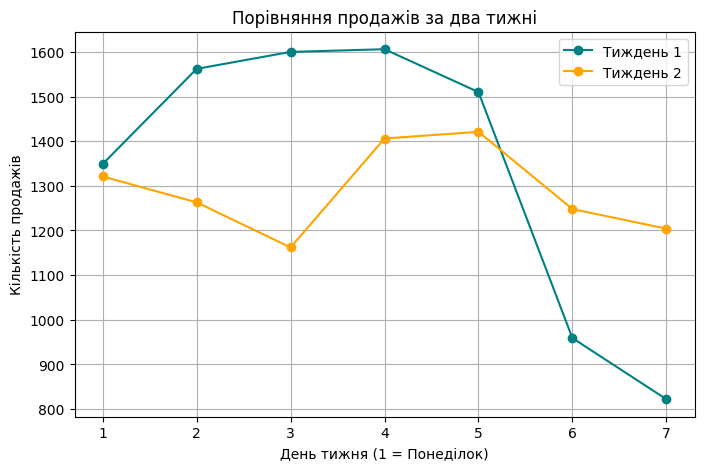

In [81]:
plt.figure(figsize=(8,5))

plt.plot(days, sales_week1, marker='o', color='teal', label='Тиждень 1')
plt.plot(days, sales_week2, marker='o', color='orange', label='Тиждень 2')

plt.title('Порівняння продажів за два тижні')
plt.xlabel('День тижня (1 = Понеділок)')
plt.ylabel('Кількість продажів')

plt.legend()
plt.grid(True)

plt.show()

In [82]:
std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)

std_week1, std_week2

(np.float64(299.99857142517004), np.float64(90.9060964256355))

# Відповідь на зпитання

1. В другому тижні були менші коливання - отже він був стабільніший.

2. Стандартне відхилення показує, наскільки сильно значення відхиляються від середнього. Чим більше число — тим більші коливання. Чим менше — тим стабільніші дані.
Продажі у другому тижні були значно стабільнішими, оскільки його стандартне відхилення (≈ 91) майже в 3 рази менше, ніж у першого тижня (≈ 300).

Перший тиждень мав сильні коливання, особливо через різке падіння у вихідні дні.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

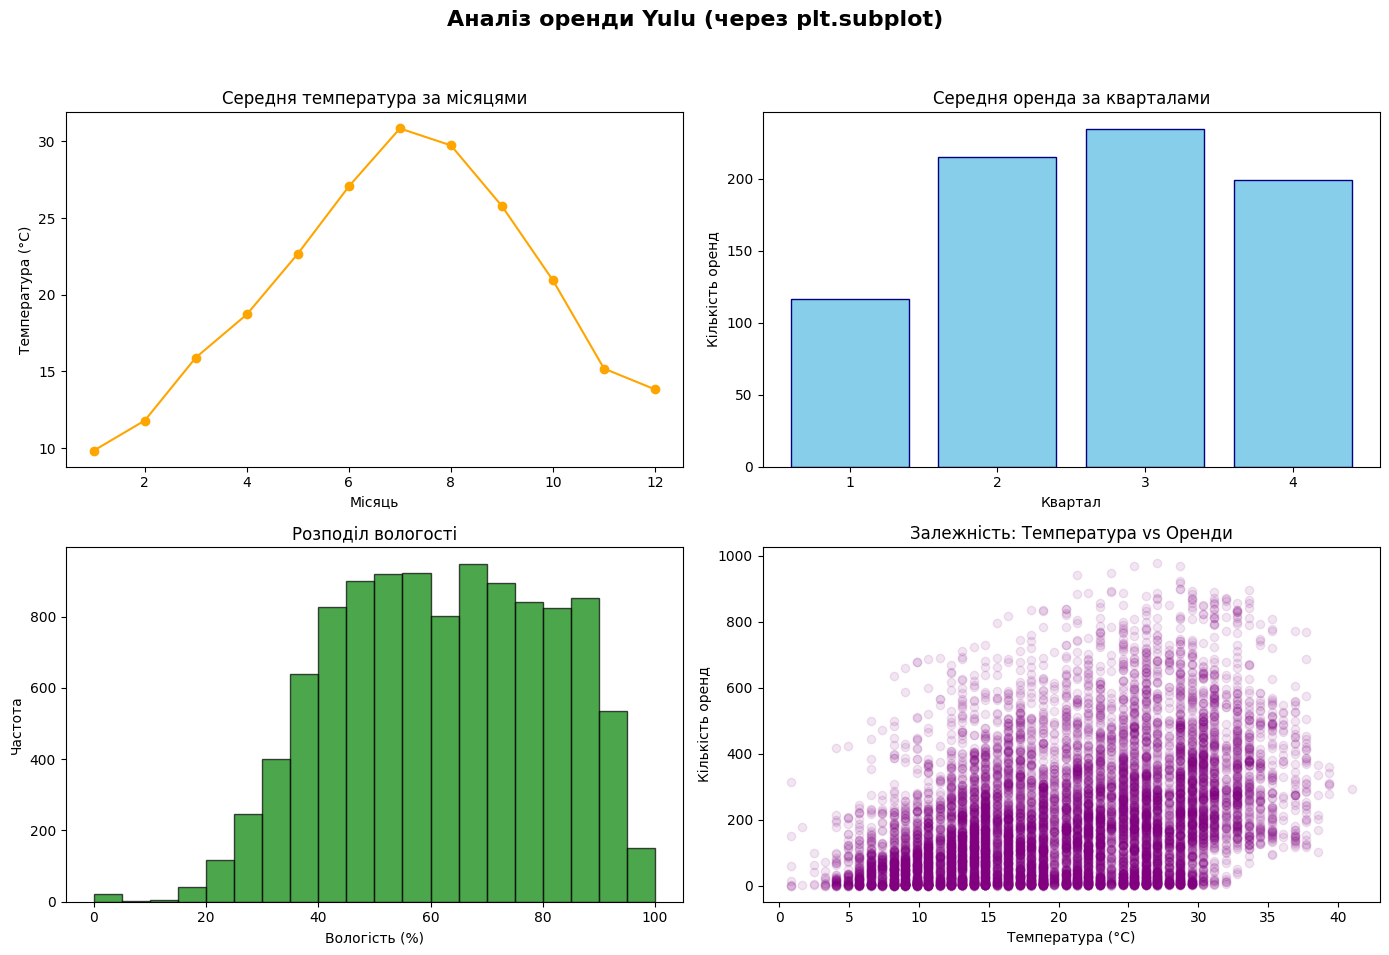

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Підготовка даних (згідно з порадою викладача)
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додавання необхідних колонок
df['month'] = df.index.month
df['quarter'] = df.index.quarter # Додаємо квартал для діаграми

# Створення сітки 2x2
plt.figure(figsize=(14, 10))
plt.suptitle('Аналіз оренди Yulu (через plt.subplot)', fontsize=16, fontweight='bold')

# 1. Лінійний графік: Температура по місяцях
plt.subplot(2, 2, 1)
temp_month = df.groupby('month')['temp'].mean()
plt.plot(temp_month.index, temp_month.values, marker='o', color='orange')
plt.title('Середня температура за місяцями')
plt.xlabel('Місяць')
plt.ylabel('Температура (°C)')

# 2. Стовпчикова діаграма: Оренди за кварталами
plt.subplot(2, 2, 2)
rent_quarter = df.groupby('quarter')['count'].mean()
plt.bar(rent_quarter.index.astype(str), rent_quarter.values, color='skyblue', edgecolor='navy')
plt.title('Середня оренда за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')

# 3. Гістограма вологості
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=20, color='green', edgecolor='black', alpha=0.7)
plt.title('Розподіл вологості')
plt.xlabel('Вологість (%)')
plt.ylabel('Частота')

# 4. Scatter plot: Температура vs Оренди
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], alpha=0.1, color='purple')
plt.title('Залежність: Температура vs Оренди')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

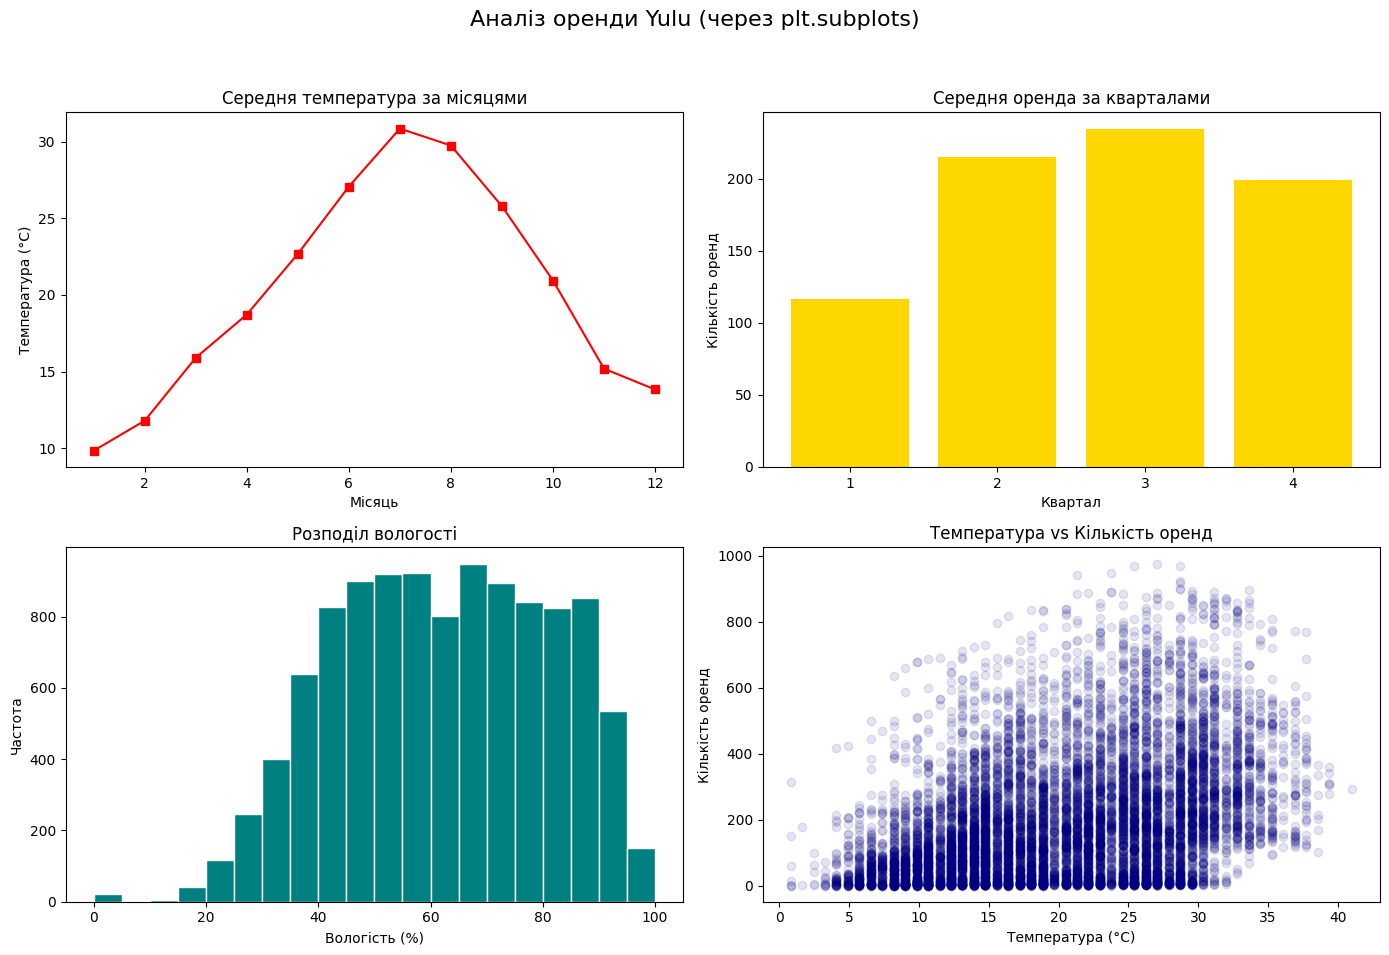

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Аналіз оренди Yulu (через plt.subplots)', fontsize=16)

# 1. Лінійний графік
axes[0, 0].plot(temp_month.index, temp_month.values, marker='s', color='red')
axes[0, 0].set_title('Середня температура за місяцями')
axes[0, 0].set_xlabel('Місяць')
axes[0, 0].set_ylabel('Температура (°C)')

# 2. Стовпчикова діаграма
axes[0, 1].bar(rent_quarter.index.astype(str), rent_quarter.values, color='gold')
axes[0, 1].set_title('Середня оренда за кварталами')
axes[0, 1].set_xlabel('Квартал')
axes[0, 1].set_ylabel('Кількість оренд')

# 3. Гістограма
axes[1, 0].hist(df['humidity'], bins=20, color='teal', edgecolor='white')
axes[1, 0].set_title('Розподіл вологості')
axes[1, 0].set_xlabel('Вологість (%)')
axes[1, 0].set_ylabel('Частота')

# 4. Scatter plot
axes[1, 1].scatter(df['temp'], df['count'], alpha=0.1, color='navy')
axes[1, 1].set_title('Температура vs Кількість оренд')
axes[1, 1].set_xlabel('Температура (°C)')
axes[1, 1].set_ylabel('Кількість оренд')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Відповідь на запитання

plt.subplot() і plt.subplots() відрізняються способом створення кількох графіків на одній фігурі.


- plt.subplot() не працює напряму з окремими об’єктами осей. Кожного разу треба перемикатись на певну область графіка і будувати його через глобальні функції plt.

- plt.subplots() створює об’єкт фігури (fig) та об’єкти осей (ax або axs). Далі кожен графік будується через конкретний об’єкт осі (наприклад, axs[0,0].plot()). Цей підхід дає більше контролю та робить код більш структурованим і зручним для складних візуалізацій.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

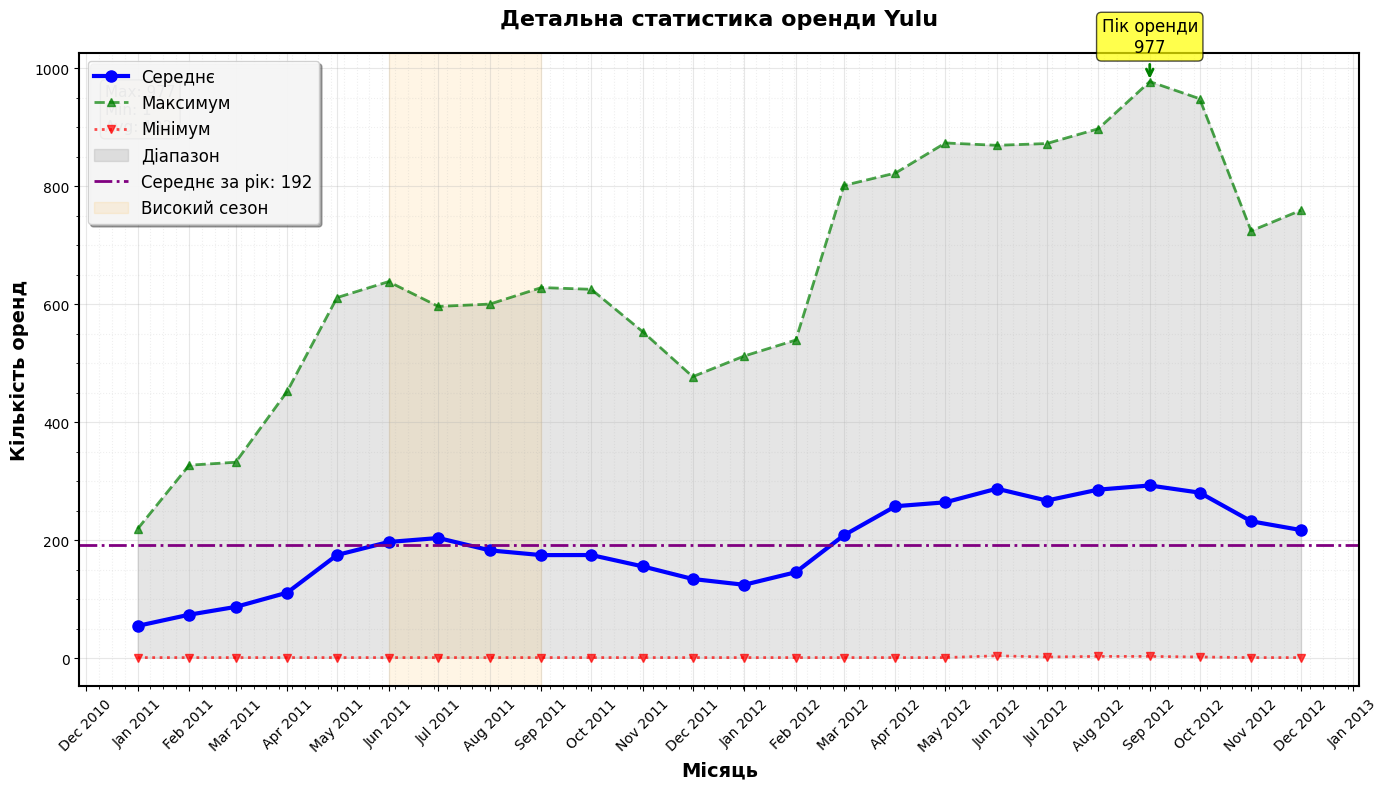

In [75]:
fig, ax = plt.subplots(figsize=(14, 8))

# 1. лінії з короткими записами стилів ('b-o', 'g--^', 'r:v')
ax.plot(monthly_stats.index, monthly_stats['mean'], 'b-o', linewidth=3,
        label='Середнє', markersize=8)
ax.plot(monthly_stats.index, monthly_stats['max'], 'g--^', linewidth=2,
        label='Максимум', markersize=6, alpha=0.7)
ax.plot(monthly_stats.index, monthly_stats['min'], 'r:v', linewidth=2,
        label='Мінімум', markersize=6, alpha=0.7)

# 2. Заливка між max та min
ax.fill_between(monthly_stats.index, monthly_stats['min'], monthly_stats['max'],
                alpha=0.2, color='gray', label='Діапазон')

# 3. Анотація для піку з жовтою плашкою (bbox)
max_idx = monthly_stats['max'].idxmax()
max_val = monthly_stats['max'].max()
ax.annotate(f'Пік оренди\n{max_val:.0f}',
            xy=(max_idx, max_val), xytext=(max_idx, max_val + 50),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))

# 4. Налаштування осей та заголовка
ax.set_xlabel('Місяць', fontsize=14, fontweight='bold')
ax.set_ylabel('Кількість оренд', fontsize=14, fontweight='bold')
ax.set_title('Детальна статистика оренди Yulu', fontsize=16, fontweight='bold', pad=20)

# 5. Форматування дат
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

# 6. Дворівнева сітка
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# 7. Середня лінія за весь період
overall_mean = df['count'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')

# 8. Виділення зони
ax.axvspan(monthly_stats.index[5], monthly_stats.index[8], alpha=0.1,
           color='orange', label='Високий сезон')

# 9. Легенда з тінню
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

# 10. Текстовий блок зі статистикою
textstr = (f'Max: {monthly_stats["max"].max():.0f}\n'
           f'Min: {monthly_stats["min"].min():.0f}\n'
           f'Avg: {overall_mean:.0f}')
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# 11. Налаштування рамки (spines)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

1. Яка перевага додавання анотацій на графік?
Анотації перетворюють "просто картинку" на історію.

Фокусування уваги: Вони миттєво спрямовують погляд глядача на найважливіші точки (піки, падіння або аномалії).

Контекст: Анотація пояснює "чому" або "скільки". Замість того, щоб вгадувати значення по осі Y, користувач бачить точну цифру або причину події.

2. Для чого використовується fill_between()?
Ця функція використовується для візуалізації діапазону або невизначеності.

Наочність коливань: Вона зафарбовує область між мінімальним та максимальним значеннями, що дозволяє оцінити стабільність даних. Якщо "коридор" вузький — дані стабільні, якщо широкий — є велика варіативність.

Естетика та ієрархія: Це створює гарний фоновий шар, який не перевантажує графік лініями, але дає зрозуміти межі, в яких рухається основний показник (середнє).

3. Як текстовий блок допомагає в інтерпретації даних?
Текстовий блок служить "швидким звітом" (Executive Summary).

Агреговані дані: Поки графік показує динаміку, текстовий блок дає підсумок: загальну суму, середнє за рік або відсоткове зростання.

Автономність: Глядачеві не потрібно мати перед очима вихідну таблицю Excel — всі ключові висновки вже винесені на візуалізацію.